# Experimento 03 (baseline/Si)

Investigar a existência de agrupamentos naturais nos dados biomecânicos da marcha do subconjunto Si utilizando K-Means sem redução dimensional.

# 1. Importando as bibliotecas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from google.colab import drive

# 2. Montando o Google Drive

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Carregando o Dataset Baseline

In [3]:
BASE_PATH = Path('/content/drive/MyDrive/results')

si_file = BASE_PATH / 'si_baseline_features.csv'

si_df = pd.read_csv(si_file)

si_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
0,Si,SiPt14_01,362.200837,390.913587,322.401322,333.247996,0.890118,0.852485,-28.712750,28.712750,877.47,937.31
1,Si,SiPt29_01,490.640455,529.150076,409.345073,428.998582,0.834308,0.810731,-38.509621,38.509621,1041.92,1085.15
2,Si,SiCo22_01,517.254519,509.153693,451.561998,443.610668,0.872998,0.871271,8.100825,8.100825,1371.59,1198.89
3,Si,SiCo01_01,361.433106,350.288006,309.265893,304.833984,0.855666,0.870238,11.145099,11.145099,791.67,787.71
4,Si,SiCo11_01,552.543424,515.343710,480.919473,453.572331,0.870374,0.880136,37.199714,37.199714,1336.94,1264.67


In [4]:
si_df.shape

(64, 12)

In [5]:
si_df.info()
si_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataset          64 non-null     object 
 1   patient_id       64 non-null     object 
 2   mean_total_L     64 non-null     float64
 3   mean_total_R     64 non-null     float64
 4   std_total_L      64 non-null     float64
 5   std_total_R      64 non-null     float64
 6   cv_total_L       64 non-null     float64
 7   cv_total_R       64 non-null     float64
 8   assimetria_mean  64 non-null     float64
 9   assimetria_abs   64 non-null     float64
 10  peak_force_L     64 non-null     float64
 11  peak_force_R     64 non-null     float64
dtypes: float64(10), object(2)
memory usage: 6.1+ KB


,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
count,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000
mean,455.527898,456.779166,397.640605,395.776659,0.873491,0.867047,-1.251269,24.538373,1096.516094,1089.737344
std,67.582103,64.221691,58.682710,55.936349,0.027140,0.030217,32.153807,20.585636,186.357551,192.820935
min,307.169540,291.983858,273.416175,265.652963,0.787837,0.783832,-84.065914,0.291942,723.910000,728.970000
25%,426.388843,417.584366,360.824622,360.703650,0.858080,0.850884,-20.753330,8.618857,985.572500,980.650000
50%,466.892141,466.664004,405.403899,399.635029,0.878268,0.865098,2.449967,18.742306,1076.955000,1091.585000
75%,493.011400,497.387626,434.342680,428.664779,0.891936,0.892212,17.474874,35.701705,1211.787500,1193.390000
max,619.271763,594.115909,535.490778,538.669684,0.934794,0.927217,79.460146,84.065914,1617.330000,1911.030000


# 4. Defininção das features

Removendo colunas não utilizadas no clustering

In [6]:
feature_cols = [
    'mean_total_L',
    'mean_total_R',

    'std_total_L',
    'std_total_R',

    'cv_total_L',
    'cv_total_R',

    'assimetria_mean',
    'assimetria_abs',

    'peak_force_L',
    'peak_force_R'
]

X = si_df[feature_cols]

# 5. Normalização dos dados

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 6. Escolha do número de clusters

## Elbow Method

In [8]:
inertia = []

k_values = range(2, 7)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

Visualizando o Elbow Method

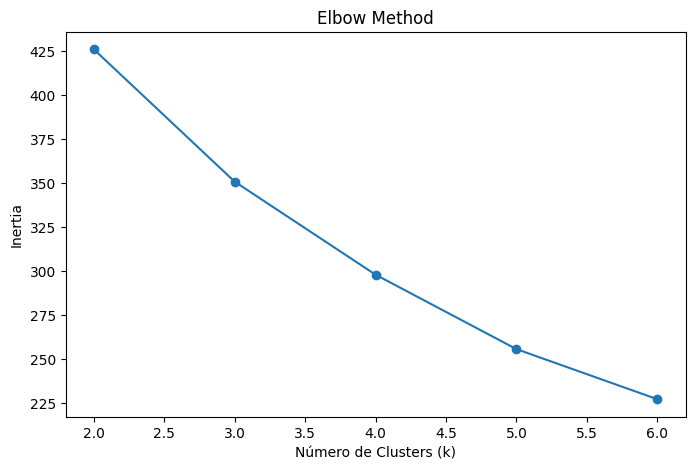

In [9]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inertia')

plt.show()

# 7. Avaliação com Silhouette Score

In [10]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f'k={k} | Silhouette Score: {score:.4f}')

k=2 | Silhouette Score: 0.3095
k=3 | Silhouette Score: 0.2334
k=4 | Silhouette Score: 0.2135
k=5 | Silhouette Score: 0.2365
k=6 | Silhouette Score: 0.2397


Vizualização com o Silhouette Score

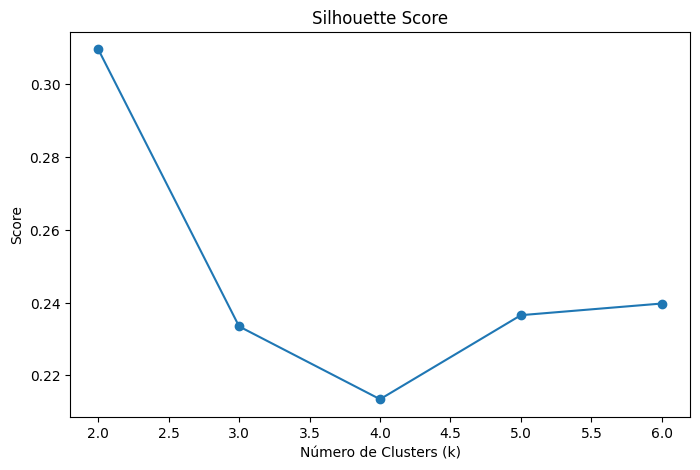

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score')

plt.show()

# 8. Treinamento final com o K-Means

In [12]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

Adicionando clusters ao dataframe

In [13]:
si_df['cluster'] = clusters

si_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R,cluster
0,Si,SiPt14_01,362.200837,390.913587,322.401322,333.247996,0.890118,0.852485,-28.712750,28.712750,877.47,937.31,1
1,Si,SiPt29_01,490.640455,529.150076,409.345073,428.998582,0.834308,0.810731,-38.509621,38.509621,1041.92,1085.15,0
2,Si,SiCo22_01,517.254519,509.153693,451.561998,443.610668,0.872998,0.871271,8.100825,8.100825,1371.59,1198.89,0
3,Si,SiCo01_01,361.433106,350.288006,309.265893,304.833984,0.855666,0.870238,11.145099,11.145099,791.67,787.71,1
4,Si,SiCo11_01,552.543424,515.343710,480.919473,453.572331,0.870374,0.880136,37.199714,37.199714,1336.94,1264.67,0


# 9. Métricas Internas

In [14]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)

davies = davies_bouldin_score(
    X_scaled,
    clusters
)

calinski = calinski_harabasz_score(
    X_scaled,
    clusters
)

print(f'Silhouette Score: {silhouette:.4f}')
print(f'Davies-Bouldin Index: {davies:.4f}')
print(f'Calinski-Harabasz Score: {calinski:.4f}')

Silhouette Score: 0.3095
Davies-Bouldin Index: 1.1740
Calinski-Harabasz Score: 31.1531


# 10. Visualização dos Clusters

PCA somente usado para visualização

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

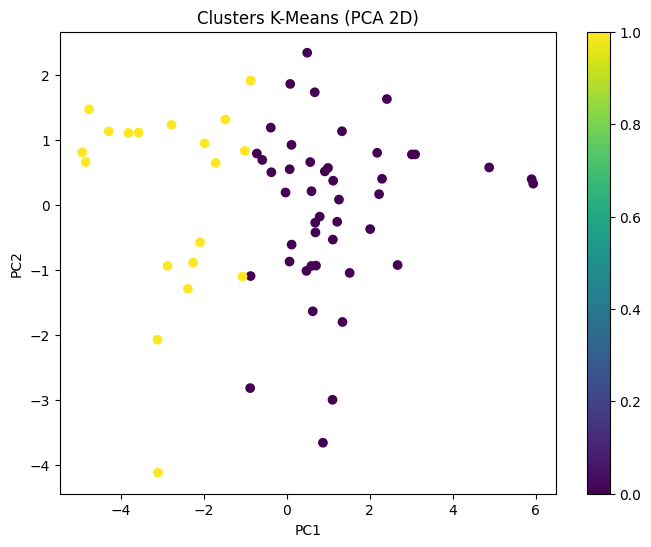

In [16]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title('Clusters K-Means (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.colorbar(scatter)

plt.show()

# 11. HeatMap dos centroídes

In [17]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols
)

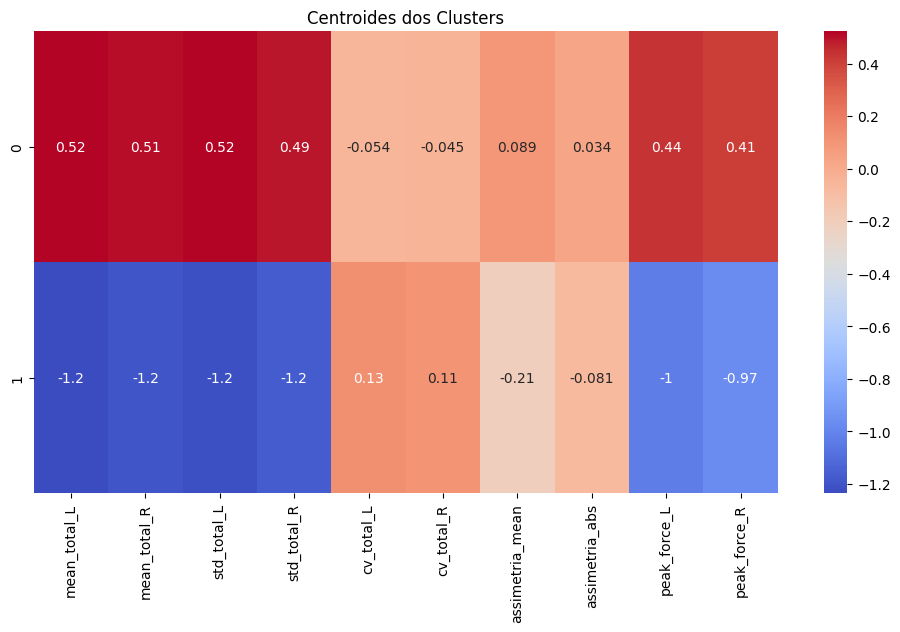

In [18]:
plt.figure(figsize=(12,6))

sns.heatmap(
    centroids,
    annot=True,
    cmap='coolwarm'
)

plt.title('Centroides dos Clusters')

plt.show()

# 12. Distribuição dos Clusters

In [19]:
si_df['cluster'].value_counts()

,count
cluster,
0,45
1,19
